In [3]:
import pandas as pd
import sys 
import os 

project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)


from src.preprocessing import preprocess_data

file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

In [4]:
df_cleaned=preprocess_data(file_path)
df_cleaned.to_csv(output_path, index=False)

df_cleaned.head(10)


Dropping columns with > 65.0% missing values: smoking


,patient_id,gender,year_of_diagnosis,rf_status,anti_ccp_status,comorbidities,visit_date,visit_type,tjc_28,sjc_28,...,treatment_decision,switch_reason,flare_event,source,birth_year,days_since_last_visit,disease_duration,age_at_visit,das28_change,target_flare_next
0,RA001,1,1997,0,0,"depression, hypothyroidism",2017-12-18,Baseline,8.0,1.0,...,NaN,No_Switch,Yes,Hospital,1970,0.0,20,47,0.00,Yes
1,RA001,1,1997,0,0,"depression, hypothyroidism",2018-03-20,Follow-up,9.0,2.0,...,Switch,Inefficacy,Yes,Hospital,1970,92.0,21,48,0.74,No
2,RA001,1,1997,0,0,"depression, hypothyroidism",2018-09-25,Follow-up,7.0,2.0,...,Switch,Inefficacy,No,Hospital,1970,189.0,21,48,-1.15,No
3,RA001,1,1997,0,0,"depression, hypothyroidism",2019-06-26,Follow-up,2.0,0.0,...,Tapering,No_Switch,No,Hospital,1970,274.0,22,49,-0.14,NaN
4,RA002,1,1999,0,0,NaN,2023-10-27,Baseline,8.0,6.0,...,NaN,No_Switch,Yes,Hospital,1983,0.0,24,40,0.00,No
5,RA002,1,1999,0,0,NaN,2024-01-30,Follow-up,0.0,0.0,...,Switch,Inefficacy,No,Hospital,1983,95.0,25,41,-1.25,No
6,RA002,1,1999,0,0,NaN,2024-04-23,Follow-up,0.0,0.0,...,Stable,No_Switch,No,Hospital,1983,84.0,25,41,-0.16,No
7,RA002,1,1999,0,0,NaN,2024-09-17,Follow-up,0.0,0.0,...,Stable,No_Switch,No,Hospital,1983,147.0,25,41,-0.84,No
8,RA002,1,1999,0,0,NaN,2025-06-10,Follow-up,0.0,0.0,...,Stable,No_Switch,No,Hospital,1983,266.0,26,42,0.96,NaN
9,RA003,0,2005,1,1,tia,2023-09-01,Baseline,NaN,NaN,...,NaN,No_Switch,No,Hospital,1963,0.0,18,60,0.00,Yes


In [33]:
df_cleaned.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 298 entries, 0 to 297
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   patient_id             298 non-null    str           
 1   gender                 298 non-null    str           
 2   year_of_diagnosis      295 non-null    Int64         
 3   smoking                67 non-null     str           
 4   rf_status              293 non-null    str           
 5   anti_ccp_status        293 non-null    str           
 6   comorbidities          217 non-null    str           
 7   visit_date             298 non-null    datetime64[us]
 8   visit_type             298 non-null    str           
 9   tjc_28                 142 non-null    float64       
 10  sjc_28                 142 non-null    float64       
 11  crp                    213 non-null    float64       
 12  crp_upper_limit        212 non-null    float64       
 13  esr             

In [20]:
missing_report = df_cleaned[['das28_score', 'crp', 'esr', 'tjc_28']].isnull().mean() * 100
print(missing_report)

das28_score    41.610738
crp            28.523490
esr            19.127517
tjc_28         52.348993
dtype: float64


Συνολικές Επισκέψεις:
flare_event
No     169
Yes    129
Name: count, dtype: int64

Ποσοστά (%):
flare_event
No     56.711409
Yes    43.288591
Name: proportion, dtype: float64


C:\Users\konna\AppData\Local\Temp\ipykernel_16180\836409855.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flare_counts.index, y=flare_counts.values, palette='viridis')


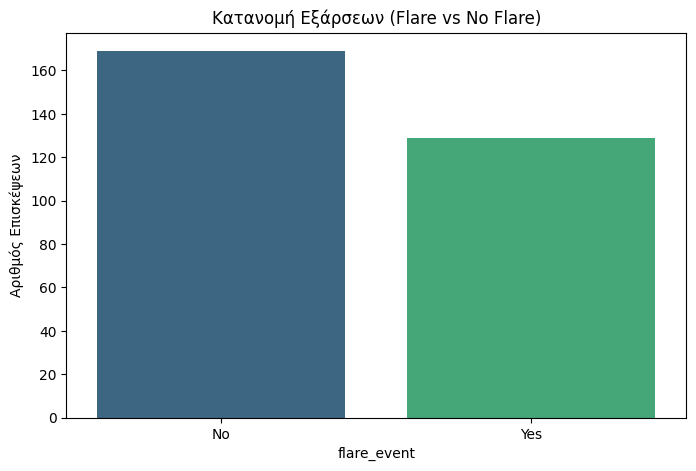

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Υπολογισμός συχνότητας
flare_counts = df_cleaned['flare_event'].value_counts()
flare_perc = df_cleaned['flare_event'].value_counts(normalize=True) * 100

print("Συνολικές Επισκέψεις:")
print(flare_counts)
print("\nΠοσοστά (%):")
print(flare_perc)

# Οπτικοποίηση
plt.figure(figsize=(8,5))
sns.barplot(x=flare_counts.index, y=flare_counts.values, palette='viridis')
plt.title('Κατανομή Εξάρσεων (Flare vs No Flare)')
plt.ylabel('Αριθμός Επισκέψεων')
plt.show()

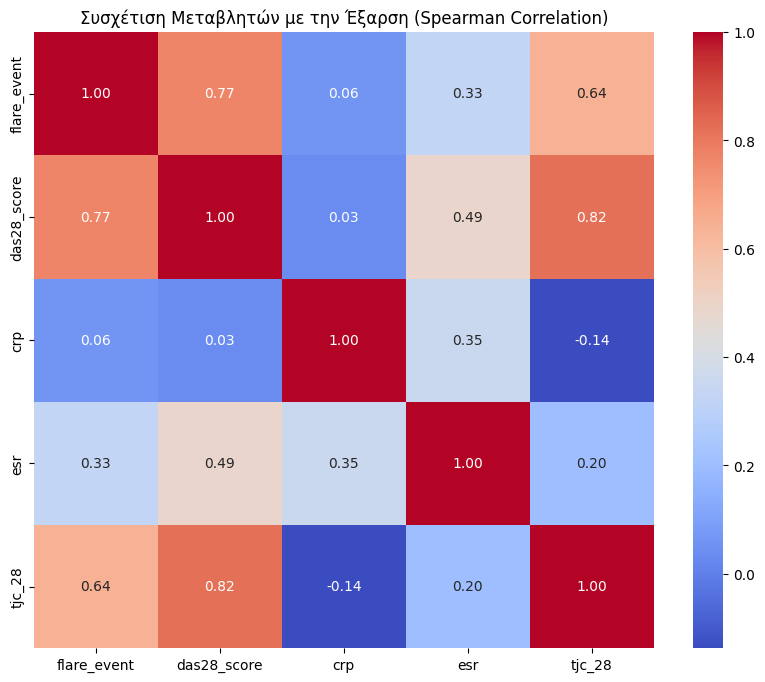

In [12]:
# Υπολογισμός συσχέτισης (χρησιμοποιούμε Spearman γιατί οι ιατρικές τιμές συχνά δεν είναι κανονικά κατανεμημένες)
corr_df = df_cleaned[['flare_event', 'das28_score', 'crp', 'esr', 'tjc_28']].copy()
corr_df['flare_event'] = corr_df['flare_event'].map({'No': 0, 'Yes': 1})
correlations = corr_df.corr(method='spearman', numeric_only=True)

# Οπτικοποίηση με Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Συσχέτιση Μεταβλητών με την Έξαρση (Spearman Correlation)')
plt.show()

In [9]:
df_cleaned.describe()

,year_of_diagnosis,visit_date,tjc_28,sjc_28,crp,crp_upper_limit,esr,vas,das28_score,mtx_dose,steroid_dose,birth_year,days_since_last_visit,disease_duration,age_at_visit
count,233.0,236,116.000000,116.000000,160.000000,159.000000,184.000000,109.000000,141.000000,235.000000,236.000000,236.0,236.000000,233.0,236.0
mean,2007.0,2021-03-14 20:38:38.644067,3.646552,1.422414,3.688594,3.021384,26.494565,40.412844,3.618085,7.476596,4.572034,1958.372881,177.707627,13.648069,62.300847
min,1981.0,2015-03-03 00:00:00,0.000000,0.000000,0.010000,0.050000,2.000000,0.000000,1.050000,0.000000,0.000000,1937.0,0.000000,0.0,37.0
25%,1999.0,2019-02-09 12:00:00,1.000000,0.000000,0.300000,0.500000,13.000000,20.000000,2.800000,0.000000,0.000000,1948.0,26.750000,3.0,54.75
50%,2011.0,2021-03-27 00:00:00,3.000000,1.000000,1.000000,5.000000,22.000000,40.000000,3.450000,0.000000,0.000000,1956.5,104.000000,11.0,63.0
75%,2015.0,2023-10-21 18:00:00,5.250000,2.000000,3.577500,5.000000,36.000000,50.000000,4.440000,15.000000,5.000000,1967.0,259.250000,21.0,72.0
max,2025.0,2026-02-24 00:00:00,25.000000,8.000000,62.500000,8.000000,105.000000,90.000000,6.800000,25.000000,500.000000,1983.0,1413.000000,44.0,84.0
std,11.749541,NaN,3.804469,1.804106,7.443581,2.490821,18.993815,21.485659,1.226886,8.634338,32.568440,11.189126,209.196180,11.969995,11.709541


In [16]:
df_cleaned.isna().sum()

patient_id                 0
gender                     0
year_of_diagnosis          3
smoking                  231
rf_status                  5
anti_ccp_status            5
comorbidities_x           81
visit_date                 0
visit_type                 0
tjc_28                   156
sjc_28                   156
crp                       85
crp_upper_limit           86
esr                       57
vas                      161
das28_score              124
csdmard_name               0
mtx_use                    0
mtx_dose                   0
b_ts_dmard_name            0
steroid_dose               0
treatment_decision        71
comorbidities_y          246
switch_reason              0
flare_event                0
source                     0
birth_year                 0
days_since_last_visit      0
disease_duration           3
age_at_visit               0
das28_change               0
target_flare_next         70
dtype: int64

In [11]:
print(f"Final dataset shape: {df_cleaned.shape}")
print(f"Number of unique patients: {df_cleaned['patient_id'].nunique()}")

Final dataset shape: (236, 29)
Number of unique patients: 55


In [6]:
# Compare averages for Flare vs No Flare
comparison = df_cleaned.groupby('flare_event')[['das28_score', 'tjc_28', 'sjc_28', 'das28_change']].mean()
print(comparison)

             das28_score    tjc_28    sjc_28  das28_change
flare_event                                               
No              2.793896  1.612903  0.403226     -0.194632
Yes             4.609687  5.981481  2.592593      0.066300


In [3]:
print(df_cleaned['target_flare_next'].value_counts(normalize=True))

target_flare_next
No     0.60221
Yes    0.39779
Name: proportion, dtype: float64


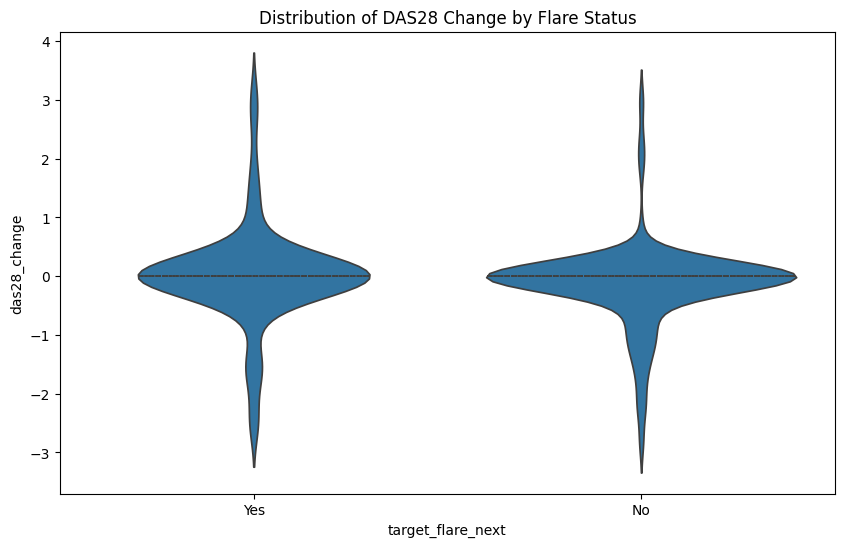

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.violinplot(x='target_flare_next', y='das28_change', data=df_cleaned, inner="quartile")
plt.title("Distribution of DAS28 Change by Flare Status")
plt.show()

Text(0.5, 1.0, 'Clinical Feature Correlation (Sanity Check)')

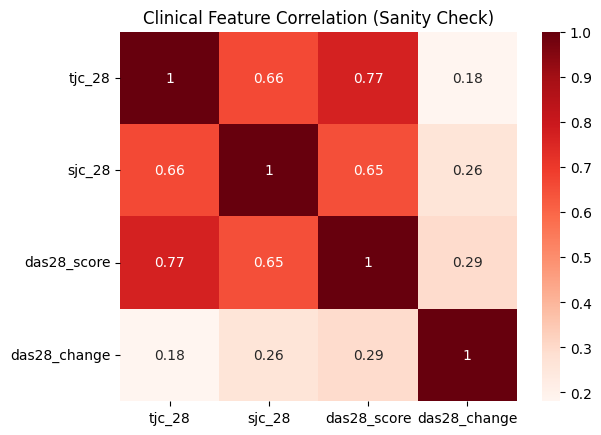

In [6]:
# Look for clinical 'Signal'
clinical_cols = ['tjc_28', 'sjc_28', 'das28_score', 'das28_change']
correlation = df_cleaned[clinical_cols].corr()

import seaborn as sns
sns.heatmap(correlation, annot=True, cmap='Reds')
plt.title("Clinical Feature Correlation (Sanity Check)")

C:\Users\konna\AppData\Local\Temp\ipykernel_16180\82281940.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='flare_event', y='steroid_dose', data=df_cleaned, palette='Set2')


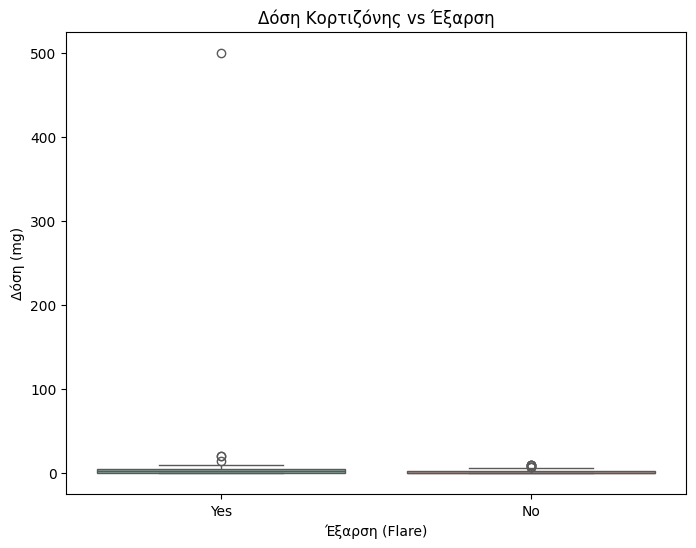

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='flare_event', y='steroid_dose', data=df_cleaned, palette='Set2')
plt.title('Δόση Κορτιζόνης vs Έξαρση')
plt.xlabel('Έξαρση (Flare)')
plt.ylabel('Δόση (mg)')
plt.show()

In [7]:
# Does treatment intensity match disease activity?
df_cleaned['is_on_biologic'] = df_cleaned['b_ts_dmard_name'].apply(lambda x: 0 if x == 'None' else 1)
print(df_cleaned.groupby('is_on_biologic')['das28_score'].mean())

is_on_biologic
0    3.846491
1    3.463095
Name: das28_score, dtype: float64


Text(0.5, 1.0, 'Missing Data Map (Yellow = Missing)')

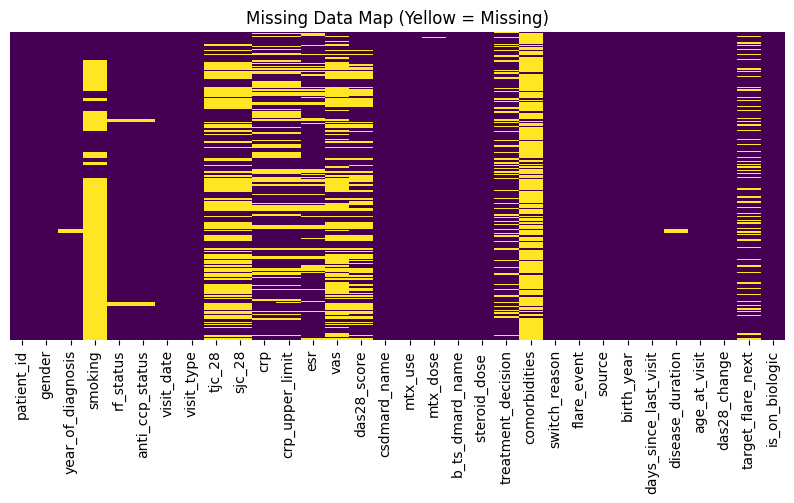

In [8]:
plt.figure(figsize=(10, 4))
sns.heatmap(df_cleaned.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Map (Yellow = Missing)")